# 03 — The policy layer: who should get the budget?

**Stage 4.** Turns the Stage 2 causal estimates into a budget-constrained
targeting decision and adjudicates **H2** (pre-registered; evaluation spec
in HYPOTHESES.md amendment A3, including the C16-mandated IPW robustness
variant). The industry default — "target likely buyers" — is the baseline
to beat: it can select exactly the customers who would have bought anyway
(*sure things*), while uplift targeting reallocates spend to
*persuadables*.

Runs on committed artifacts (`results/stage4/`, Stage 2 OOF predictions,
dev parquet); every displayed number is asserted.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong import data
from how_wrong.policy import incremental_conversions

STAGE4 = data.PROJECT_ROOT / "results" / "stage4"
res = json.loads((STAGE4 / "policy_results.json").read_text())
curves = pd.read_csv(STAGE4 / "curves_conversion.csv")
curves_v = pd.read_csv(STAGE4 / "curves_visit.csv")
roi = pd.read_csv(STAGE4 / "roi.csv")
oof = pd.read_parquet(data.PROJECT_ROOT / "results/stage2/oof_cate.parquet")
dev = data.load_criteo_dev()

BLUE, GREEN, MUTED, INK = "#2a78d6", "#008300", "#6b6a63", "#1a1a19"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e5e4dd", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
})
# spot-check: stored curve point recomputable from committed artifacts
v = incremental_conversions(dev["conversion"], dev["treatment"],
                            oof["conversion_dr_learner"], 0.30)
assert v == curves.loc[(curves.k - 0.3).abs() < 1e-9, "cate"].iloc[0]
f"loaded; spec: {res['spec']}"


'loaded; spec: HYPOTHESES.md amendment A3'

## 1. The money chart — three targeting policies

Estimated incremental conversions (dev 1M, out-of-fold scores) when
treating the top k% ranked by: DR-learner uplift, propensity-to-convert,
or nothing in particular (random). Stars mark the pre-registered H2
budgets.

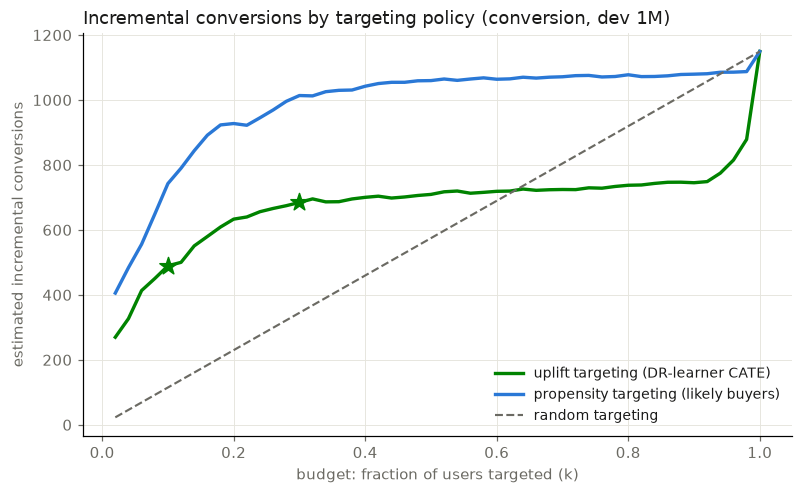

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(curves.k, curves["cate"], color=GREEN, lw=2.2,
        label="uplift targeting (DR-learner CATE)")
ax.plot(curves.k, curves["propensity"], color=BLUE, lw=2.2,
        label="propensity targeting (likely buyers)")
ax.plot(curves.k, curves["random"], color=MUTED, lw=1.4, ls="--",
        label="random targeting")
for k in (0.10, 0.30):
    r = curves.loc[(curves.k - k).abs() < 1e-9].iloc[0]
    ax.scatter([k], [r["cate"]], color=GREEN, marker="*", s=140, zorder=3)
ax.set_xlabel("budget: fraction of users targeted (k)")
ax.set_ylabel("estimated incremental conversions")
ax.set_title("Incremental conversions by targeting policy (conversion, dev 1M)",
             loc="left", color=INK)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()


## 2. H2 — the pre-registered verdict

Δ(k) = incremental(uplift-ranked) − incremental(propensity-ranked) at
k = 10% and 30%; joint bootstrap (B = 500), support requires Δ > 0 with the
95% CI excluding 0 at **both** budgets (intersection–union). The IPW
variant re-runs everything with ê-weighted means — the C16 merge-artifact
robustness check.

In [3]:
h2 = res["h2"]
rows = []
for variant, d in (("primary", h2["primary"]), ("ipw_robust", h2["ipw_robust"])):
    for key in ("k10", "k30"):
        r = d[key]
        rows.append({"variant": variant, "k": r["k"], "delta": r["delta"],
                     "ci_lo": r["ci_lo"], "ci_hi": r["ci_hi"],
                     "p_boot": r["p_boot"]})
tab = pd.DataFrame(rows).set_index(["variant", "k"])
display(tab.round(2))

assert h2["p_h2"] == max(h2["primary"]["k10"]["p_boot"],
                         h2["primary"]["k30"]["p_boot"])
print(f"p_H2 = {h2['p_h2']:.4f}")
print(f"raw verdict (Δ>0, CI excl. 0 at both k): {h2['verdict_h2_raw']}")
print(f"IPW-robust variant agrees: {h2['robust_agrees']}")


delta   ci_lo   ci_hi  p_boot
variant    k                                  
primary    0.1 -253.32 -374.30 -120.95     0.0
           0.3 -329.18 -444.07 -199.91     0.0
ipw_robust 0.1 -316.51 -434.96 -191.95     0.0
           0.3 -348.48 -461.31 -219.70     0.0

p_H2 = 0.0020
raw verdict (Δ>0, CI excl. 0 at both k): False
IPW-robust variant agrees: True


## 3. ROI translation (exploratory, stated assumptions)

Profit(k) = $40 × incremental conversions − $0.15 × targeted users —
assumptions are illustrative (A3). Note the ROI curve is computed for the
*uplift* policy; given the H2 verdict above, the propensity ranking is
currently the better conversion policy at the tested budgets, so read this
as the economics of budget-constrained targeting in general (interior
optimum, sensitivity to cost/value), not as a victory lap.

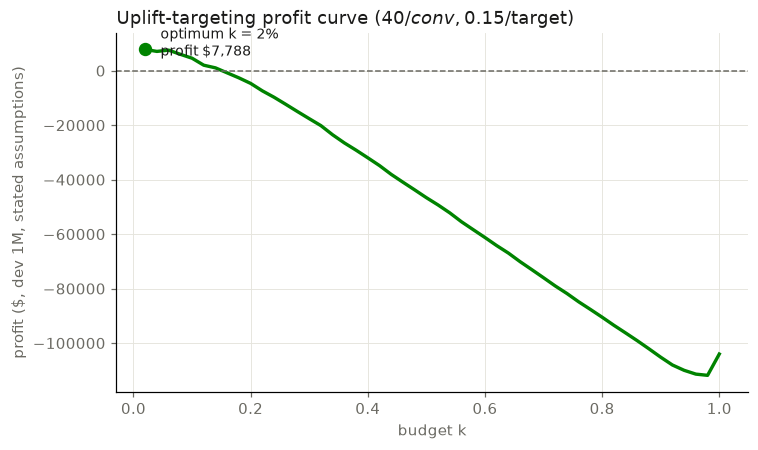

cost $/target,0.05,0.15,0.50
value $/conv,,,
20.0,0.06,0.02,0.02
40.0,0.18,0.02,0.02
80.0,1.00,0.10,0.02


In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(roi.k, roi.profit, color=GREEN, lw=2.2)
best = roi.loc[roi.profit.idxmax()]
ax.scatter([best.k], [best.profit], color=GREEN, s=60, zorder=3)
ax.annotate(f"optimum k = {best.k:.0%}\nprofit ${best.profit:,.0f}",
            (best.k, best.profit), textcoords="offset points",
            xytext=(10, -4), fontsize=9, color=INK)
ax.axhline(0, color=MUTED, lw=1, ls="--")
ax.set_xlabel("budget k")
ax.set_ylabel("profit ($, dev 1M, stated assumptions)")
ax.set_title("Uplift-targeting profit curve ($40/conv, $0.15/target)",
             loc="left", color=INK)
plt.tight_layout(); plt.show()

sens = pd.DataFrame(res["roi_sensitivity"])
display(sens.pivot(index="value", columns="cost", values="k_opt")
        .rename_axis(index="value $/conv", columns="cost $/target"))


## 4. Why the textbook story didn't happen here

Two reasons, and the second is the interesting one.

**Noise:** on `conversion` the DR-learner's CATE is barely signal at 1M
rows (Stage 2: its Qini CI includes zero — as the Stage 1 power analysis
predicted). Ranking by a noise-dominated estimate costs real conversions.

**No sure things:** the classic quadrant argument — "propensity targeting
wastes budget on people who'd buy anyway" — requires *saturated* customers,
i.e. base rates near 1 at the top of the propensity ranking. At a 0.3%
conversion (4.7% visit) rate, essentially nobody is saturated: treatment
effects in this data scale *with* baseline propensity, so "most likely to
convert" and "most persuadable" are nearly the same people — and the
propensity model ranks them with far less variance than any CATE estimate.
The exploratory `visit` curves confirm it's not just noise: even with a
strong CATE signal, the propensity ranking still edges out the uplift
ranking at every tested budget. The sure-things trap needs sure things;
rare-outcome ad targeting has none.

In [5]:
k10 = curves.loc[(curves.k - 0.10).abs() < 1e-9].iloc[0]
k10v = curves_v.loc[(curves_v.k - 0.10).abs() < 1e-9].iloc[0]
k30v = curves_v.loc[(curves_v.k - 0.30).abs() < 1e-9].iloc[0]
print("conversion, k=10% (H2, adjudicated above):")
print(f"  uplift-ranked:    {k10['cate']:>8.0f} incremental conversions")
print(f"  propensity-ranked:{k10['propensity']:>8.0f}")
print(f"  random:           {k10['random']:>8.0f}")
print("visit, k=10% and 30% (exploratory — strong CATE signal, same story):")
print(f"  k=10%: uplift {k10v['cate']:.0f} vs propensity {k10v['propensity']:.0f} "
      f"vs random {k10v['random']:.0f}")
print(f"  k=30%: uplift {k30v['cate']:.0f} vs propensity {k30v['propensity']:.0f} "
      f"vs random {k30v['random']:.0f}")
# both policies crush random; propensity edges uplift on both outcomes
assert k10v["propensity"] > k10v["cate"] > k10v["random"]


conversion, k=10% (H2, adjudicated above):
  uplift-ranked:         489 incremental conversions
  propensity-ranked:     743
  random:                115
visit, k=10% and 30% (exploratory — strong CATE signal, same story):
  k=10%: uplift 4990 vs propensity 5050 vs random 1034
  k=30%: uplift 7653 vs propensity 8152 vs random 3103


## Verdict

- **H2 is rejected on the pre-registered test** — at both budgets the
  uplift ranking *underperforms* propensity targeting on conversion, CI
  excluding zero, and the IPW-robust variant agrees. This is an honest
  negative result: uplift modelling is not automatically better; it needs
  enough signal to rank on, and a 0.3% base rate at 1M rows doesn't
  provide it.
- The visit contrast (exploratory) shows it isn't only noise: with rare
  outcomes, uplift scales with baseline propensity, so the likely-buyer
  ranking is a near-optimal uplift ranking — the sure-things trap requires
  saturated customers, and there are none at these base rates. Both
  policies crush random targeting; the fancy one just doesn't beat the
  simple one here.
- Family status: H1 (p = 9.9e-23) and H3 (p = 4.5e-29) survive Holm across
  H1–H3 at α = 0.05 regardless of ordering; H2 is rejected. Final formal
  adjudication is recorded in Stage 5.

In [6]:
assert res["spec"] == "HYPOTHESES.md amendment A3"
print("notebook 03 assertions: ALL GREEN")


notebook 03 assertions: ALL GREEN
